## HenonNet surrogate evaluation

In [1]:
# %% Load HenonNet model and training data
import sys, os

import jax
import jax.numpy as jnp
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bin.negative_triangularity.train_henonnet import HenonNet

# --- Load data ---
d = np.load('./data/training_data.npz')
X_all = d['data'].astype(np.float32)    # (N, 2): [Lphi,  varphi ]
Y_all = d['labels'].astype(np.float32)  # (N, 2): [Lphi', varphi']

# --- Normalization (must match what was used during training) ---
y_vals = np.concatenate([X_all[:, 1], Y_all[:, 1]])
ymean  = float(y_vals.mean())
ydiam  = float(y_vals.std())

# --- Rebuild model skeleton and deserialise weights ---
HENONNET_PATH = './data/henonnet.eqx'
UNIT_LIST     = [32, 32, 32, 32]   # must match --layers used during training
SEED          = 0

key   = jax.random.PRNGKey(SEED)
model = HenonNet(UNIT_LIST, key, ymean, ydiam)
model = eqx.tree_deserialise_leaves(HENONNET_PATH, model)
print('Model loaded from', HENONNET_PATH)


Model loaded from ./data/henonnet.eqx


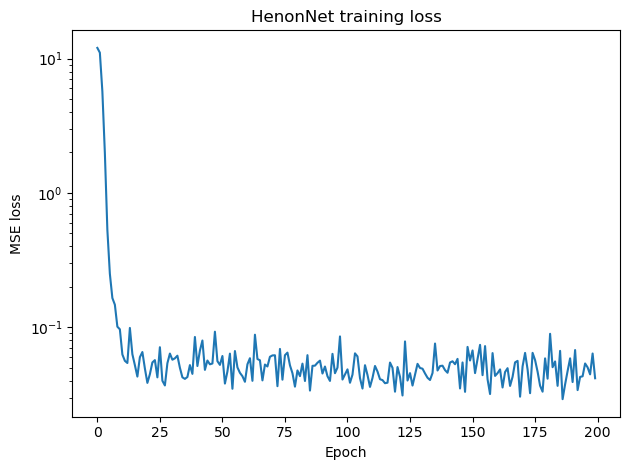

In [2]:
# %% Training loss history
losses = np.load('./data/henonnet_losses.npy')

fig, ax = plt.subplots()
ax.semilogy(losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('HenonNet training loss')
plt.tight_layout()


RMSE  Lphi   = 3.137e-03
RMSE  varphi = 3.174e-01


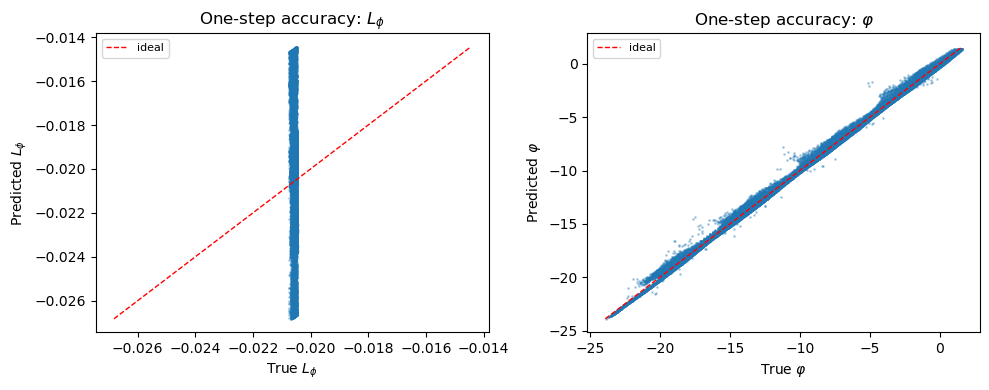

In [3]:
# %% One-step prediction accuracy
X_jax   = jnp.array(X_all)
Y_pred  = jax.vmap(model)(X_jax)   # (N, 2)
Y_pred_np = np.array(Y_pred)

residuals   = Y_pred_np - Y_all
rmse_lphi   = float(np.sqrt(np.mean(residuals[:, 0]**2)))
rmse_varphi = float(np.sqrt(np.mean(residuals[:, 1]**2)))
print(f"RMSE  Lphi   = {rmse_lphi:.3e}")
print(f"RMSE  varphi = {rmse_varphi:.3e}")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
labels_cols = [r"$L_\phi$", r"$\varphi$"]
for col, lbl in enumerate(labels_cols):
    ax = axs[col]
    ax.scatter(Y_all[:, col], Y_pred_np[:, col], s=1, alpha=0.3)
    lo = min(Y_all[:, col].min(), Y_pred_np[:, col].min())
    hi = max(Y_all[:, col].max(), Y_pred_np[:, col].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='ideal')
    ax.set_xlabel(f"True {lbl}")
    ax.set_ylabel(f"Predicted {lbl}")
    ax.set_title(f"One-step accuracy: {lbl}")
    ax.legend(fontsize=8)
plt.tight_layout()


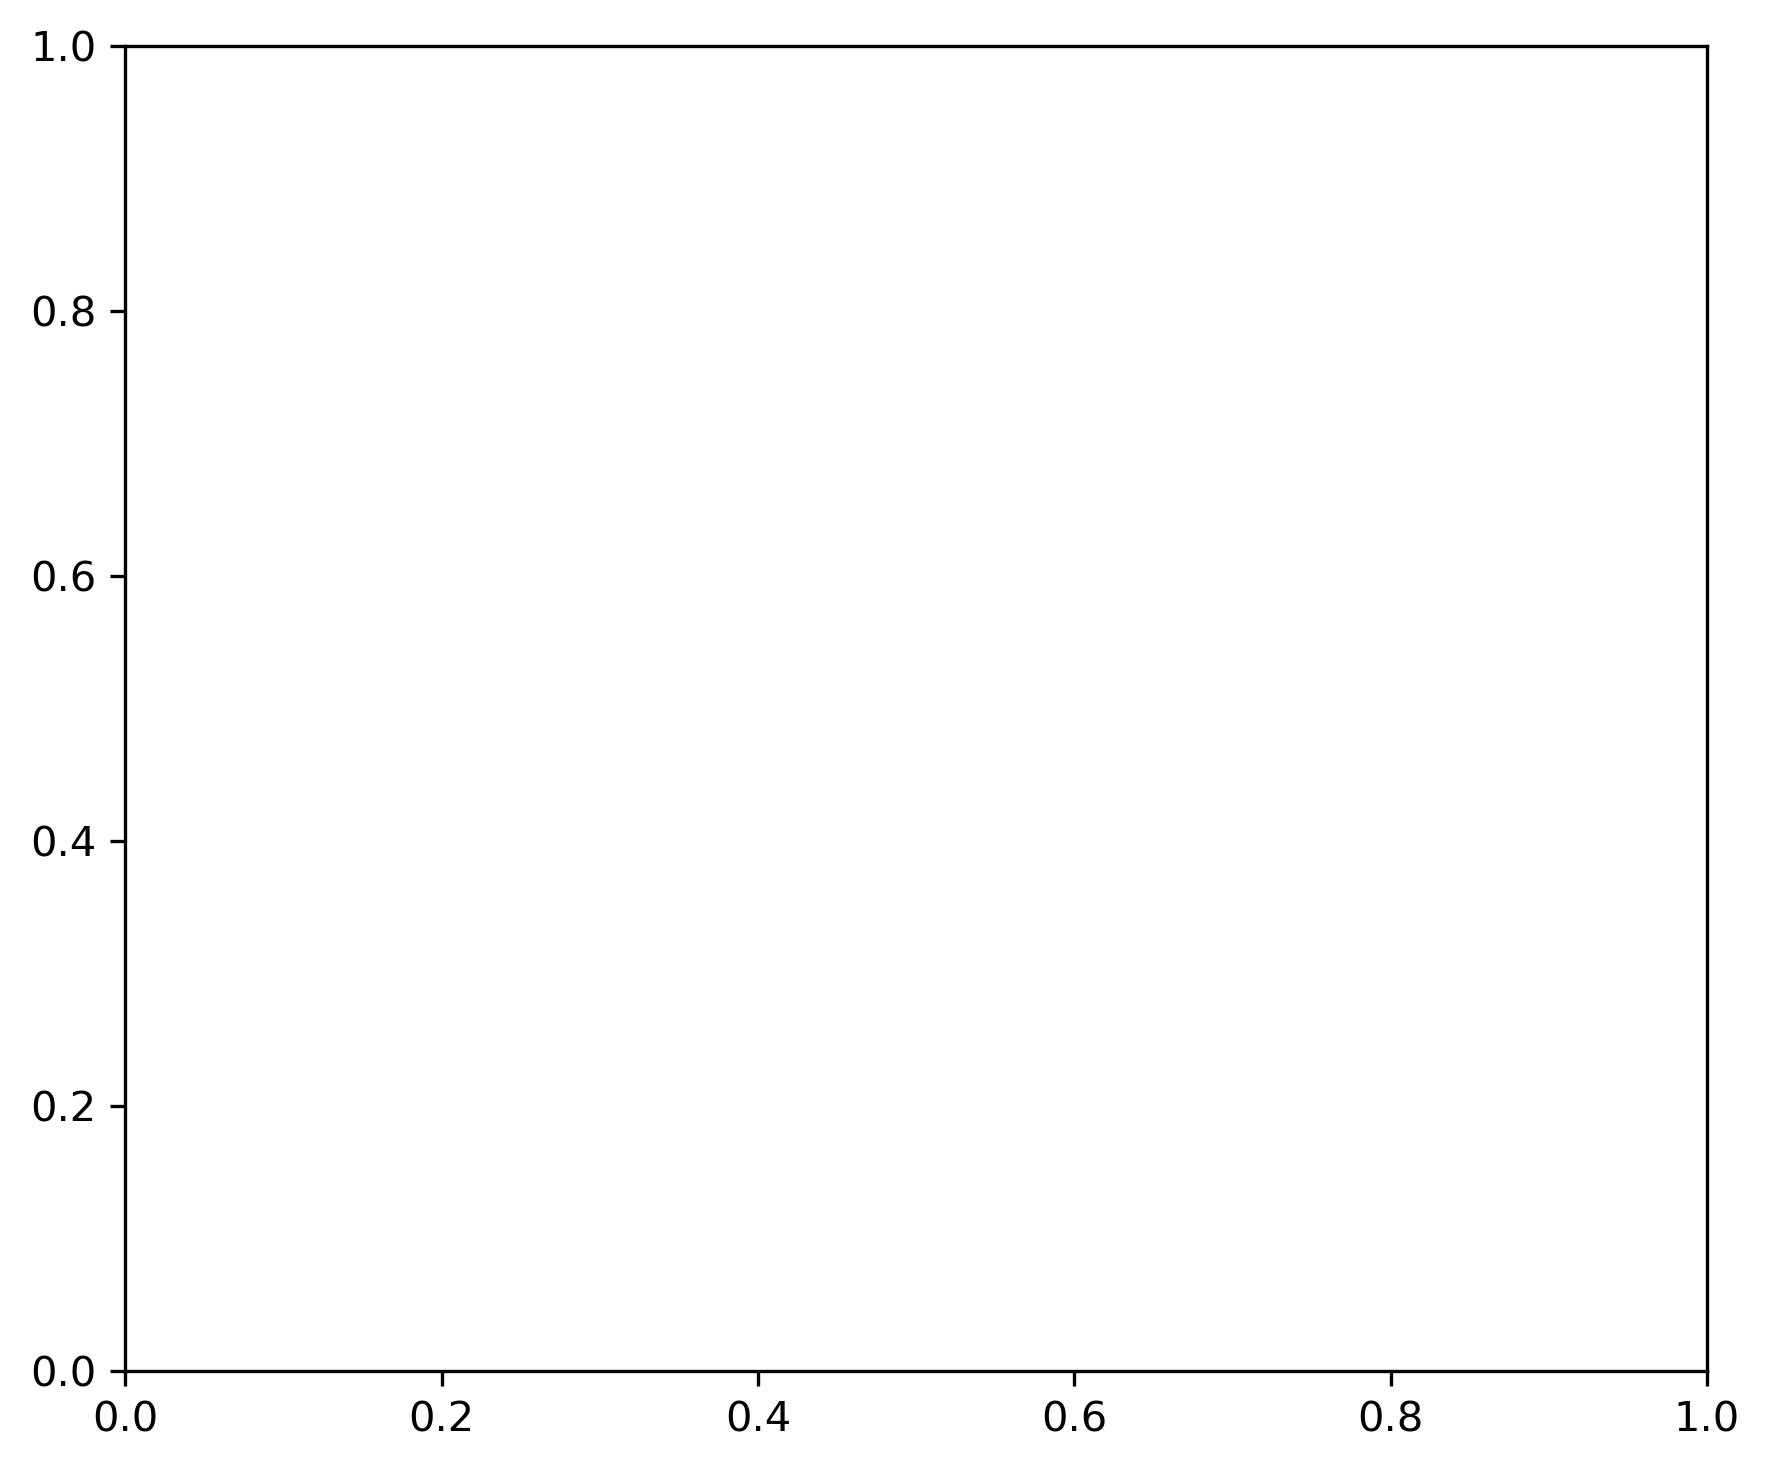

In [ ]:
# %% Poincar� portrait: true data vs HenonNet multi-step iteration
# Pick a subset of initial conditions and iterate the HenonNet.

N_orbits    = 48        # number of initial conditions
N_crossings = 1024       # map iterations per orbit

# Seed ICs from evenly-spaced indices across the dataset
ic_idx = np.linspace(0, len(X_all) - 1, N_orbits, dtype=int)
z      = jnp.array(X_all[ic_idx])

traj = np.zeros((N_crossings, N_orbits, 2))
for k in range(N_crossings):
    z = jax.vmap(model)(z)
    traj[k] = np.array(z)



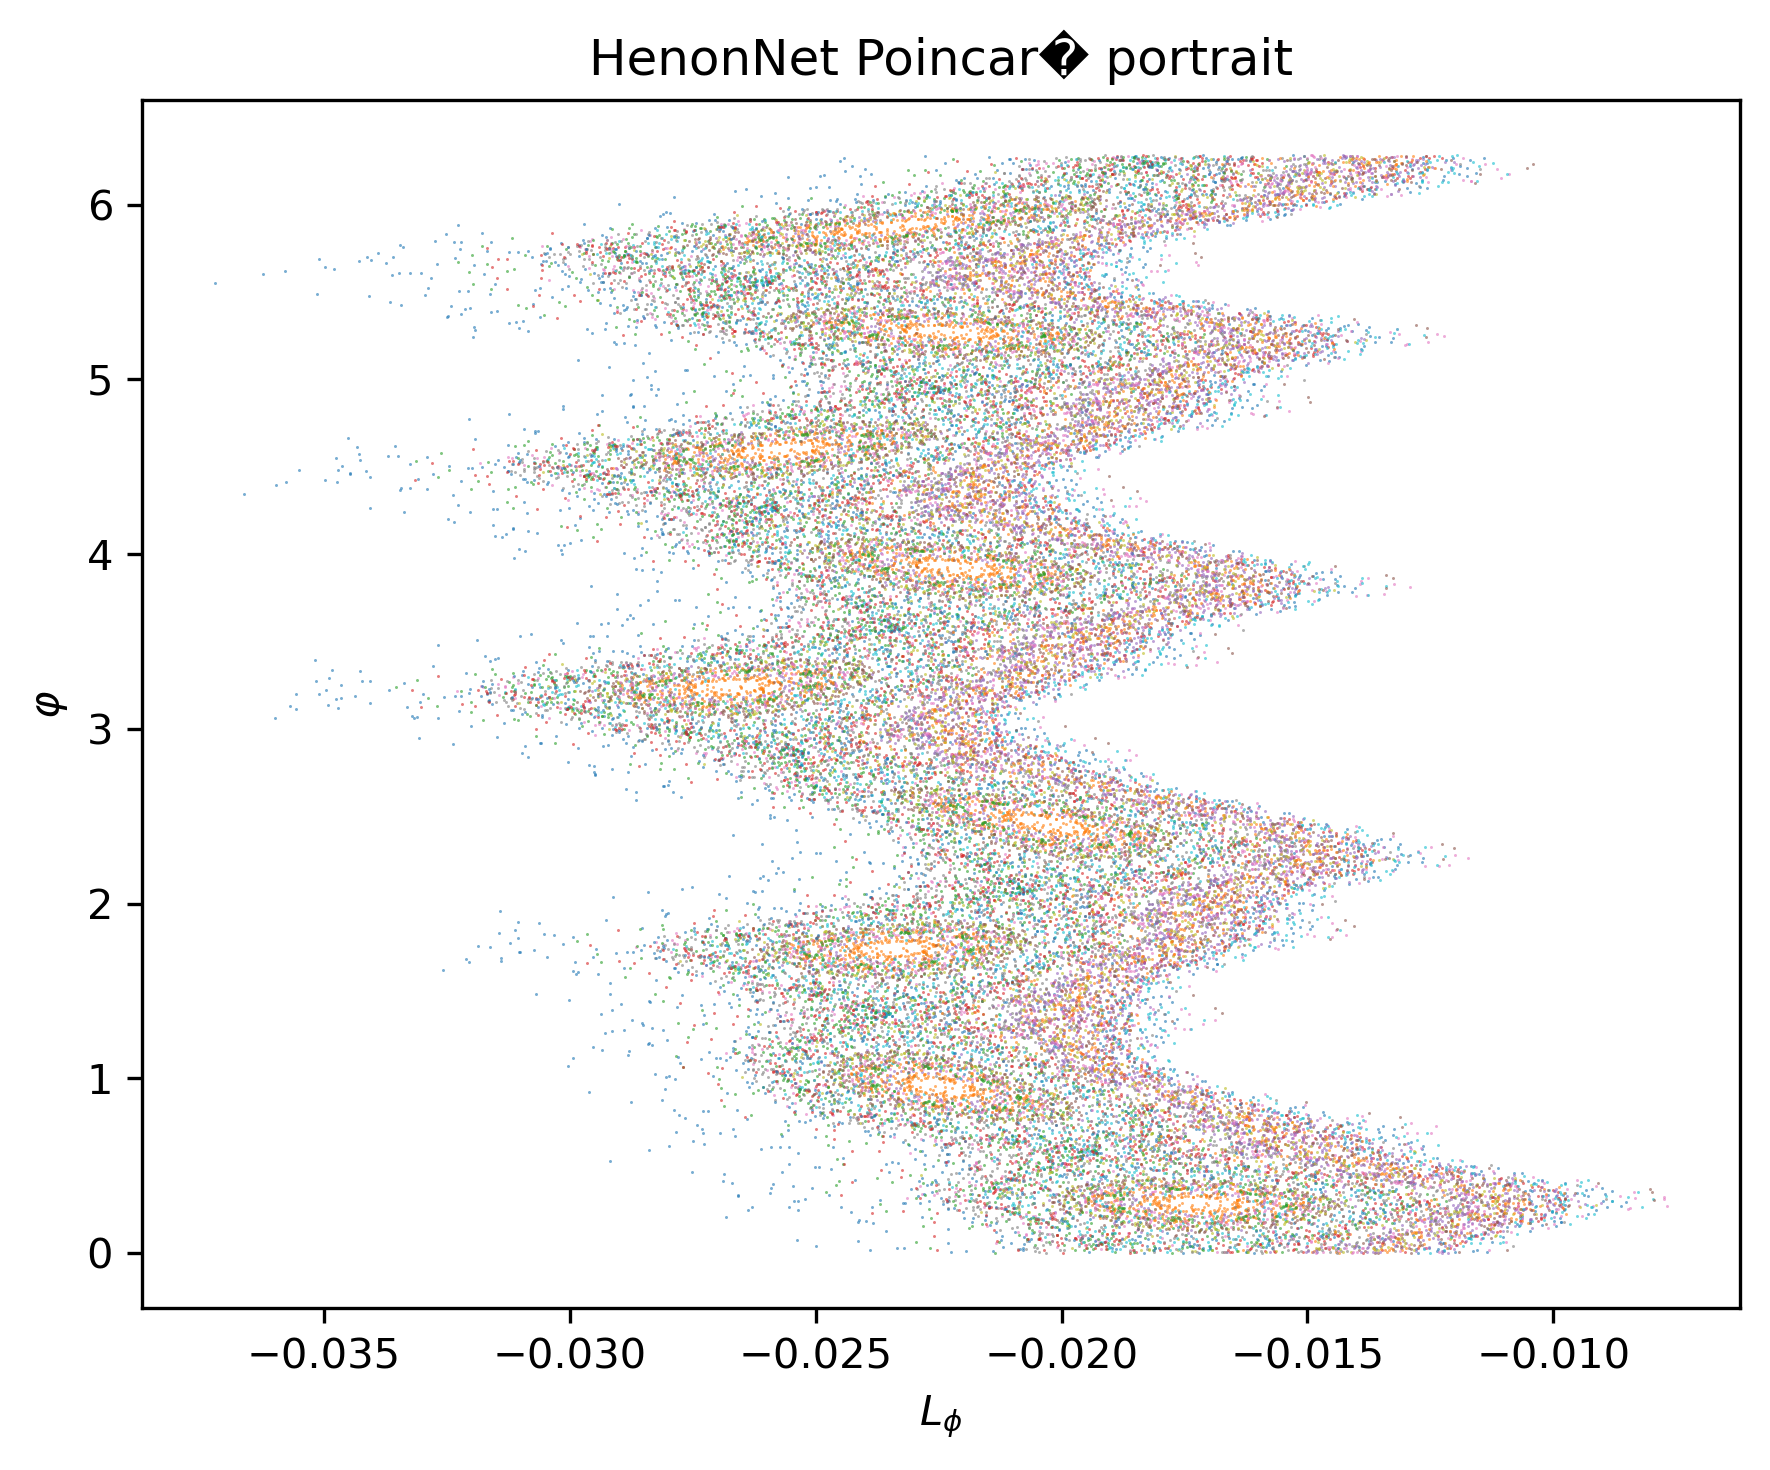

In [11]:

fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=300)
for k in range(N_orbits):
    ax.scatter(traj[:, k, 0], np.mod(traj[:, k, 1], 2*np.pi), s=(72.0/100.0)**2, alpha=0.6, lw=0.0)
ax.set_xlabel(r"$L_\phi$")
ax.set_ylabel(r"$\varphi$")
ax.set_title("HenonNet Poincar� portrait")

plt.tight_layout()

det(Jf):  mean=1.000000  std=1.76e-07  min=0.999999  max=1.000001


ValueError: Too many bins for data range. Cannot create 50 finite-sized bins.

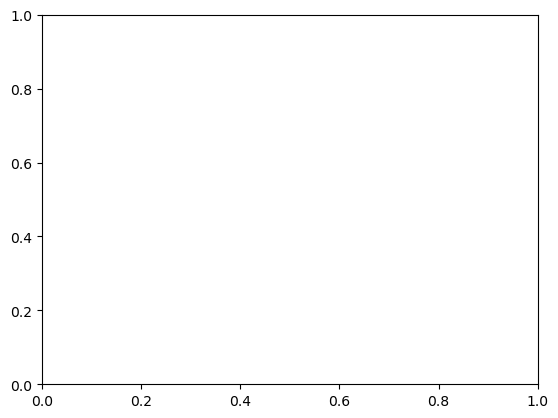

In [6]:
# %% Symplecticity check: Jacobian determinant should be 1 everywhere
J_all   = jax.vmap(jax.jacobian(model))(X_jax)   # (N, 2, 2)
det_all = J_all[:, 0, 0]*J_all[:, 1, 1] - J_all[:, 0, 1]*J_all[:, 1, 0]
det_np  = np.array(det_all)

print("det(Jf):  mean={:.6f}  std={:.2e}  min={:.6f}  max={:.6f}".format(
    det_np.mean(), det_np.std(), det_np.min(), det_np.max()))

fig, ax = plt.subplots()
ax.hist(det_np, bins=50)
ax.axvline(1.0, color='r', ls='--', label='ideal (det=1)')
ax.set_xlabel('det(Jf)')
ax.set_ylabel('count')
ax.set_title('Jacobian determinant (symplecticity check)')
ax.legend()
plt.tight_layout()
